# NEURAL NEBULA: SUBMISSION

$$
\begin{array}{|l|l|}
\hline
\textbf{Team Name:} & Bias \ And \ Variance \\\hline
\textbf{Member 1:} & Gaurav \ Negi\\\hline
\textbf{Member 2:} & Akshat \ Awasthi\\\hline
\textbf{Branch:} & Electrical \ Engineering \\\hline
\textbf{Year:} & 1^{st} \\\hline
\textbf{Submission Number:} & 1 \\\hline
\end{array}
$$

## Import libraries and Load dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("train.csv")
df

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-238 c,Kepler-238,1,5,Transit,2014.0,Kepler,6.155557,2.390000,152.522000,...,287.897107,40.637814,0,Mini-Neptune,False,True,False,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
1,Kepler-1843 b,Kepler-1843,1,1,Transit,2021.0,Kepler,25.543400,2.709098,7.800000,...,292.885230,41.279169,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
2,TOI-5734 b,TOI-5734,1,1,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),6.184188,2.100000,9.100000,...,111.255818,37.231122,0,Mini-Neptune,False,False,True,Nearby(<100pc),K-type,Short(1-10d)
3,HD 31253 b,HD 31253,1,1,Radial Velocity,2010.0,W. M. Keck Observatory,466.000000,14.100000,197.054600,...,73.682288,12.352010,0,Gas Giant,False,False,False,Nearby(<100pc),F-type,Very-Long(365d+)
4,TOI-762 A b,TOI-762 A,2,1,Transit,2024.0,Transiting Exoplanet Survey Satellite (TESS),3.471683,8.339482,79.774930,...,166.074742,-47.821496,0,Gas Giant,False,False,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,K2-3 d,K2-3,1,3,Transit,2015.0,K2,44.556030,1.458000,2.200000,...,172.335371,-1.455136,0,Super-Earth,True,True,False,Nearby(<100pc),K-type,Medium(10-100d)
4916,TOI-444 b,TOI-444,1,1,Transit,2023.0,Transiting Exoplanet Survey Satellite (TESS),17.963600,2.770000,8.100000,...,64.183998,-26.766407,0,Mini-Neptune,False,False,True,Nearby(<100pc),G-type(Sun-like),Medium(10-100d)
4917,HD 175541 b,HD 175541,1,1,Radial Velocity,2007.0,W. M. Keck Observatory,298.430000,14.100000,190.062340,...,283.920321,4.264934,0,Gas Giant,False,False,False,Mid(100-500pc),K-type,Long(100-365d)
4918,HD 81688 b,HD 81688,1,1,Radial Velocity,2007.0,Okayama Astrophysical Observatory,183.930000,13.500000,525.688185,...,142.166575,45.600924,0,Gas Giant,False,False,False,Nearby(<100pc),K-type,Long(100-365d)


# Question 1 (Easy Level)
### Show dataset info (dtypes/nulls). Identify the earliest discovery year and list the name and facility of the first 5 planets found then.

In [2]:
# 1. Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   planet_name           4920 non-null   object 
 1   host_star             4920 non-null   object 
 2   n_stars               4920 non-null   int64  
 3   n_planets             4920 non-null   int64  
 4   discovery_method      4920 non-null   object 
 5   disc_year             4919 non-null   float64
 6   disc_facility         4920 non-null   object 
 7   orbital_period_days   4662 non-null   float64
 8   planet_radius_earth   4884 non-null   float64
 9   planet_mass_earth     4894 non-null   float64
 10  equilibrium_temp_k    3679 non-null   float64
 11  orbital_eccentricity  4171 non-null   float64
 12  semi_major_axis_au    4665 non-null   float64
 13  star_temp_k           4695 non-null   float64
 14  star_radius_sun       4673 non-null   float64
 15  star_mass_sun        

In [3]:
# 2. Find earliest year
earliest_year = df['disc_year'].min()
print(f"\nEarliest Discovery Year: {int(earliest_year)}")


Earliest Discovery Year: 1992


In [4]:
# 3. Name and facility of first five planets
first_discoveries = df.sort_values(by='disc_year', ascending=True).head(5)
print(first_discoveries[['planet_name', 'disc_facility']])

         planet_name               disc_facility
21    PSR B1257+12 c         Arecibo Observatory
2269  PSR B1257+12 d         Arecibo Observatory
3961  PSR B1257+12 b         Arecibo Observatory
4413        51 Peg b  Haute-Provence Observatory
400         47 UMa b            Lick Observatory


# Insight:
## The dataset contains a mix of numeric (float/int) and categorical (object) data. The earliest year (1992) marks the era of Pulsar Timing discoveries, showing that exoplanet science predates the major satellite missions.

# Question 2 (Easy)
## Identify the most common discovery method (disc_method). Display value counts of all discovery methods sorted in descending order.

In [5]:
method_counts = df['discovery_method'].value_counts()
most_common = method_counts.index[0]

print(f"The most common discovery method is: {most_common}")
print("\nFull Value Counts (Descending):")
print(method_counts)

The most common discovery method is: Transit

Full Value Counts (Descending):
discovery_method
Transit                          3612
Radial Velocity                   948
Microlensing                      213
Imaging                            77
Transit Timing Variations          32
Eclipse Timing Variations          16
Orbital Brightness Modulation       8
Pulsar Timing                       7
Astrometry                          5
Disk Kinematics                     1
Pulsation Timing Variations         1
Name: count, dtype: int64


## Insight: As expected, 'Transit' dominates the dataset. This is largely due to the high-throughput nature of the Kepler and TESS missions.

# Question 3 (Easy)
## Calculate how many exoplanets were discovered each year (disc_year). Create a bar chart showing discoveries per year.

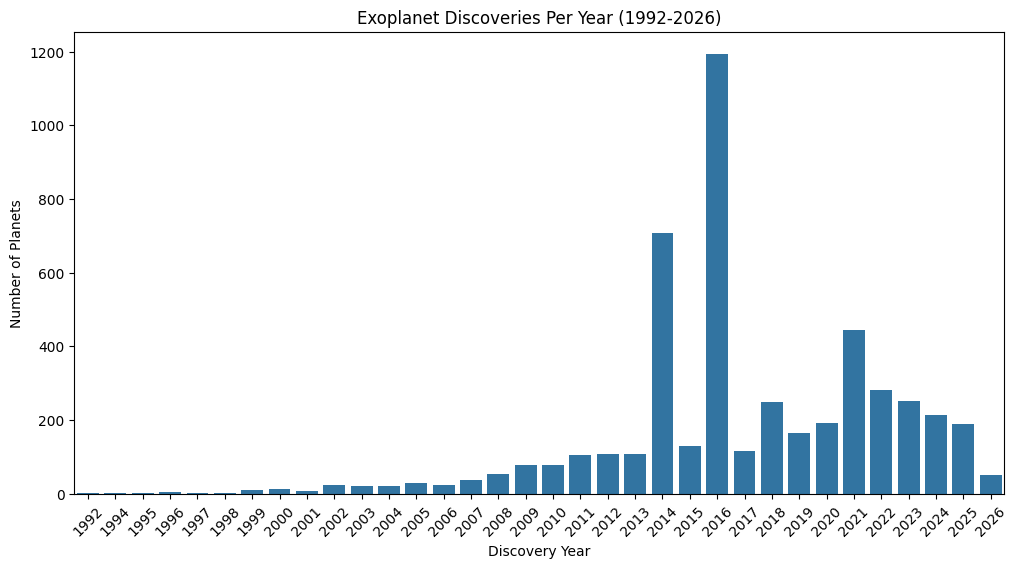

In [6]:
plt.figure(figsize=(12, 6))
yearly_discoveries = df['disc_year'].value_counts().sort_index()

# Barplot of yearly discoveries and their values
sns.barplot(x=yearly_discoveries.index.astype(int), y=yearly_discoveries.values)
plt.xticks(rotation=45)
plt.title('Exoplanet Discoveries Per Year (1992-2026)')
plt.xlabel('Discovery Year')
plt.ylabel('Number of Planets')
plt.show()

## Insight: The bar chart highlights major 'surges' in discoveries (e.g., 2014 and 2016). These peaks correlate with the release of large data batches from the Kepler Space Telescope.

# Question 4 (Easy)
## List the top 10 discovery facilities (disc_facility) that discovered the highest number of exoplanets.

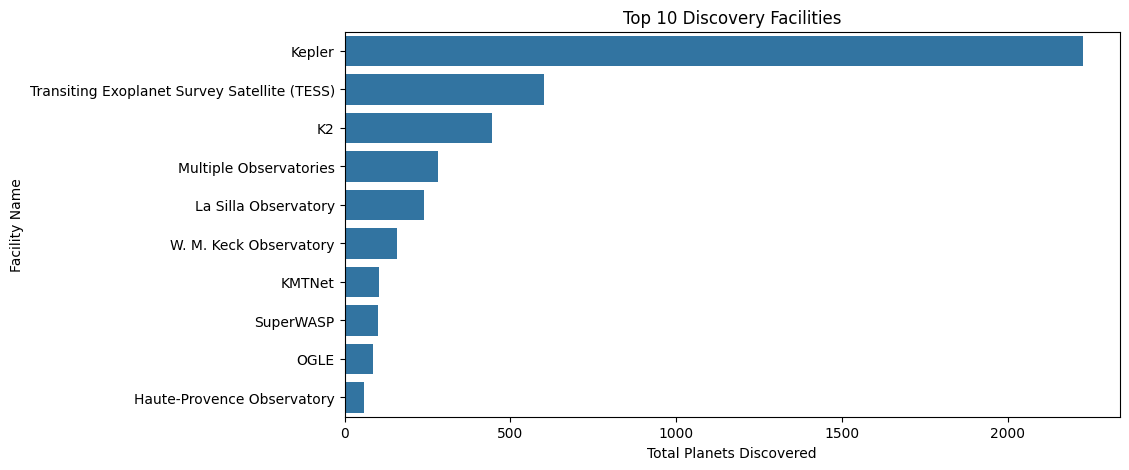

In [7]:
top_10_facilities = df['disc_facility'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_facilities.values, y=top_10_facilities.index)
plt.title('Top 10 Discovery Facilities')
plt.xlabel('Total Planets Discovered')
plt.ylabel('Facility Name')
plt.show()

## Insight: The Kepler mission is the most productive facility, followed by TESS.

# Question 6 (Intermediate Level)
## Determine how many planets have a radius smaller than Earth (pl_rade < 1). Identify the top 3 discovery methods responsible for finding these planets.

In [8]:
small_planets = df[df['planet_radius_earth'] < 1.0] # Filter for planets smaller than Earth
print(f"Total planets found with radius < 1 Earth Radius: {len(small_planets)}")

# Top 3 methods
top_3_small_methods = small_planets['discovery_method'].value_counts().head(3)
print("\nTop 3 Methods for finding small planets:")
print(top_3_small_methods)

Total planets found with radius < 1 Earth Radius: 194

Top 3 Methods for finding small planets:
discovery_method
Transit                      183
Radial Velocity                7
Transit Timing Variations      2
Name: count, dtype: int64


## Insight: Out of thousands of entries, only 194 are smaller than Earth. The Transit method is the clear leader here (183 detections), proving that high-precision space telescopes like Kepler and TESS are our best tools for finding 'Earth-like' worlds.

# Question 7 (Intermediate Level)
## Perform missing value analysis: count null values in each column, compute percentage of missing values, and identify the top 3 columns with highest missing data.

In [9]:
# Count nulls and calculate percentages
missing_data = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Null Count', ascending=False)

top_3_missing = missing_data.head(3) # Identify top 3 columns

print(missing_data)
print("\nTop 3 Columns with highest missing data:")
print(top_3_missing)

                      Null Count  Percentage (%)
equilibrium_temp_k          1241       25.223577
star_age_gyr                1064       21.626016
orbital_eccentricity         749       15.223577
star_metallicity             444        9.024390
orbital_period_days          258        5.243902
semi_major_axis_au           255        5.182927
star_surface_gravity         247        5.020325
star_radius_sun              247        5.020325
star_vmag                    231        4.695122
star_temp_k                  225        4.573171
planet_radius_earth           36        0.731707
planet_mass_earth             26        0.528455
dist_from_earth_pc            23        0.467480
star_mass_sun                  7        0.142276
disc_year                      1        0.020325
controversial_flag             0        0.000000
habitable_zone_flag            0        0.000000
multi_planet_system            0        0.000000
is_recent_discovery            0        0.000000
dist_category       

## Insight: Significant gaps in 'equilibrium_temp_k' and 'star_age_gyr' suggest that atmospheric and age-related stellar properties are harder to observe than basic orbital parameters.

# Question 8 (Intermediate Level)

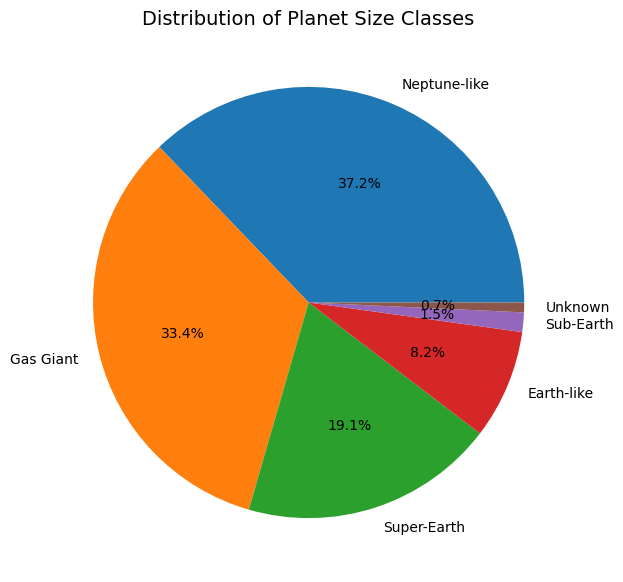

In [10]:
def classify_planet_size(radius): # Define the classification logic
    if pd.isna(radius): return 'Unknown'
    if radius < 0.8: return 'Sub-Earth'
    elif radius < 1.25: return 'Earth-like'
    elif radius < 2.0: return 'Super-Earth'
    elif radius < 6.0: return 'Neptune-like'
    else: return 'Gas Giant'

df['planet_size_class'] = df['planet_radius_earth'].apply(classify_planet_size) # Create the new column

plt.figure(figsize=(10, 7))

size_counts = df['planet_size_class'].value_counts()
plt.pie(size_counts, labels=size_counts.index, autopct='%1.1f%%') #Pie chart showing distribution of planet size classes
plt.title('Distribution of Planet Size Classes', fontsize=14)

plt.show()

## Insight: The pie chart shows that Neptune-like planets and Gas Giants dominate the catalog. This does not necessarily mean they are more common in the universe; rather, they are easier to detect. 'Sub-Earths' represent the smallest slice.

# Question 9 (Advanced Level)

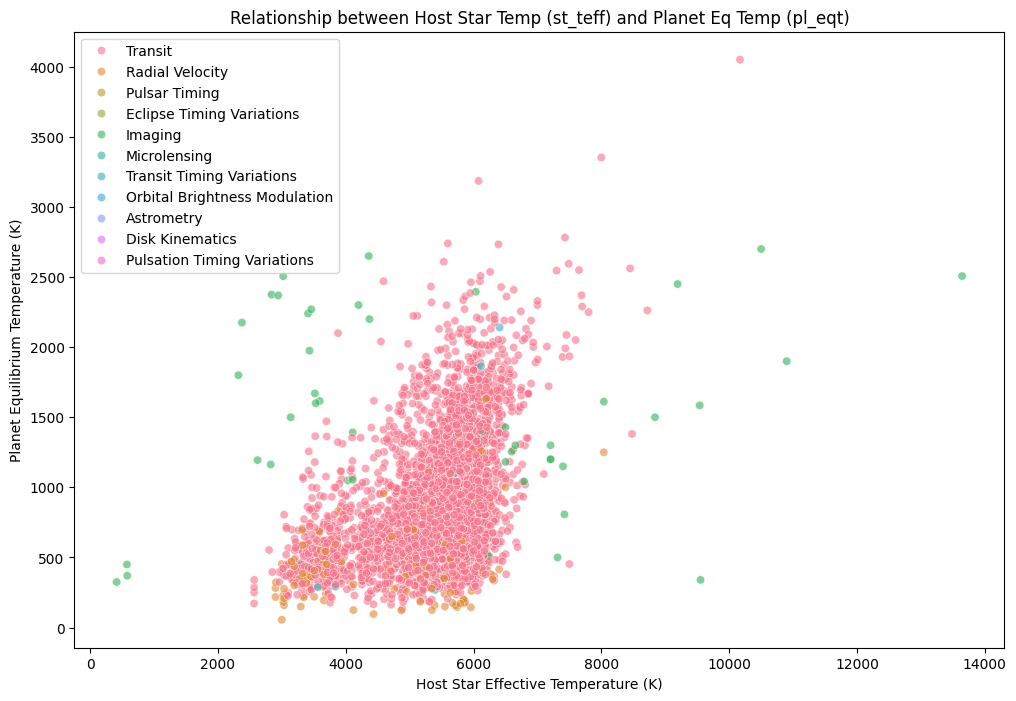

In [11]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='star_temp_k', y='equilibrium_temp_k', hue='discovery_method', alpha=0.6)

# Formatting
plt.title('Relationship between Host Star Temp (st_teff) and Planet Eq Temp (pl_eqt)')
plt.xlabel('Host Star Effective Temperature (K)')
plt.ylabel('Planet Equilibrium Temperature (K)')
plt.legend()
plt.show()

## Insight: The scatter plot generally shows a positive correlation: hotter stars tend to host hotter planets.

# Question 11 (Advanced Level)

In [12]:
missing_pct = df.isnull().mean() * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

equilibrium_temp_k      25.223577
star_age_gyr            21.626016
orbital_eccentricity    15.223577
star_metallicity         9.024390
orbital_period_days      5.243902
semi_major_axis_au       5.182927
star_radius_sun          5.020325
star_surface_gravity     5.020325
star_vmag                4.695122
star_temp_k              4.573171
planet_radius_earth      0.731707
planet_mass_earth        0.528455
dist_from_earth_pc       0.467480
star_mass_sun            0.142276
disc_year                0.020325
dtype: float64


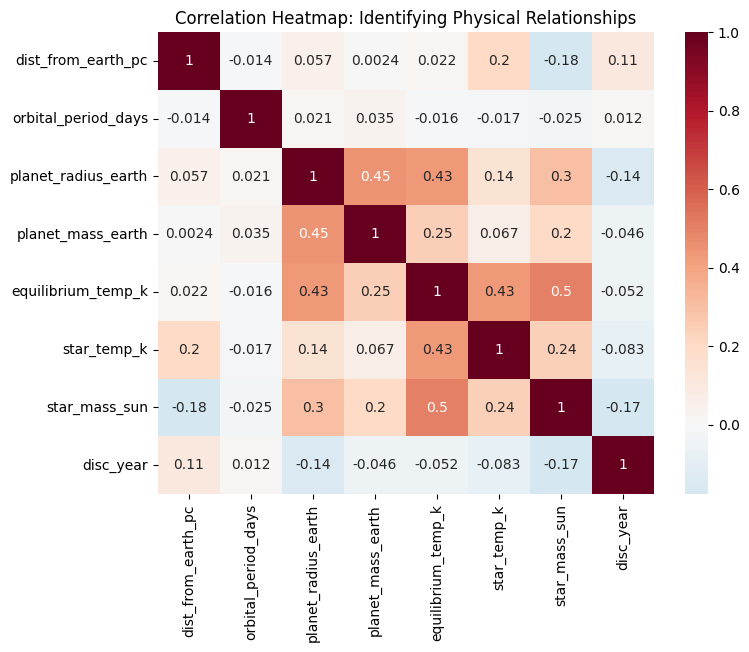

In [13]:
numeric_features = [
    'dist_from_earth_pc', 'orbital_period_days', 'planet_radius_earth', 
    'planet_mass_earth', 'equilibrium_temp_k', 'star_temp_k','star_mass_sun',
    'disc_year'
]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='RdBu_r', center=0) # This line calculates the Pearson correlation and plots it as a heatmap.
plt.title('Correlation Heatmap: Identifying Physical Relationships')
plt.show()

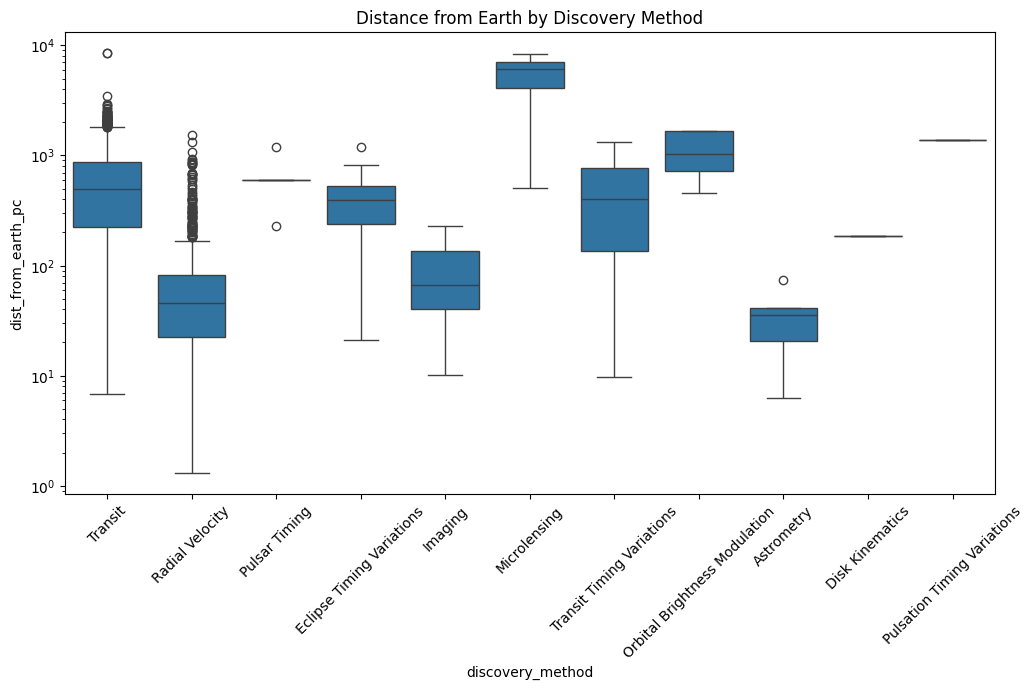

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='discovery_method', y='dist_from_earth_pc')
plt.yscale('log') # Log scale because distances vary from 1pc to 8000pc
plt.xticks(rotation=45)
plt.title('Distance from Earth by Discovery Method')
plt.show()

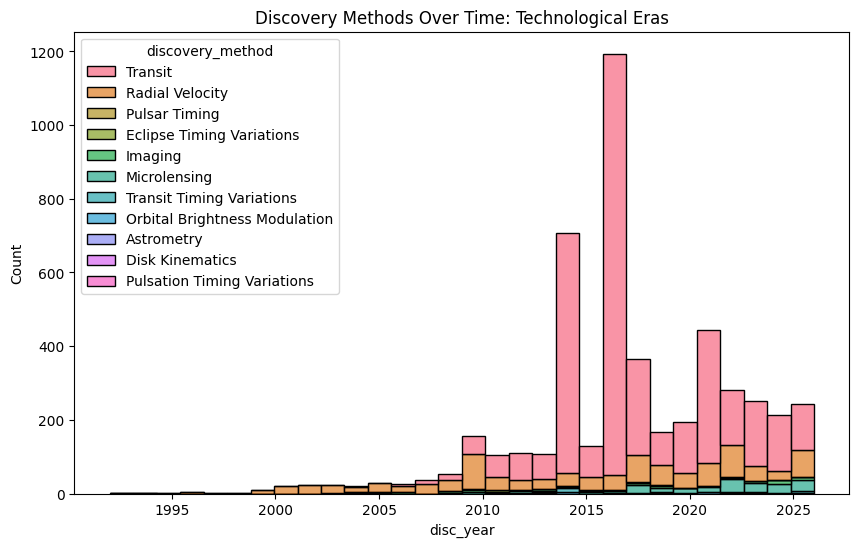

In [15]:
# We plot a histogram of discovery years to see the technological shifts over time.
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='disc_year', hue='discovery_method', multiple="stack", bins=30)
plt.title('Discovery Methods Over Time: Technological Eras')
plt.show()

## Summary of EDA Findings

### Star Temp vs. Planet Temp (~0.43): There is a clear positive correlation here. As expected by physics, hotter stars host hotter planets. This justifies including both, as they tell a consistent story.
### Radius vs. Mass (~0.45): This moderate correlation is crucial. It shows that while bigger planets are often heavier, the relationship isn't perfect (due to differences in density, like Gas Giants vs. Rocky planets)
### Because the center is at 0, you can see that disc_year has very little linear correlation with physical properties, suggesting that physics remains constant even as our technology (the year) changes.
### Boxplot proves why dist_from_earth_pc is a "Key Feature"—it is one of the few variables that can almost single-handedly distinguish Microlensing from the other methods.
### In histogram, we can see a massive surge in Transit discoveries starting around 2009–2014. This justifies including disc_year.

In [16]:
# Feature Selection
key_features = [
    'disc_facility',      # Mission specialization
    'orbital_period_days', # pl_orbper (Geometry/Distance from star)
    'planet_radius_earth', # pl_rade (Physical size - Transit bias)
    'planet_mass_earth',   # pl_masse (Gravity/Wobble - RV bias)
    'dist_from_earth_pc',  # sy_dist (Distance reach)
    'equilibrium_temp_k',  # pl_eqt (Proximate orbit indicator)
    'star_temp_k',         # st_teff (Host star environment)
    'star_mass_sun',       # st_mass (Star gravity effect)
    'disc_year']            # Technological era

# Preprocessing
# Fill numeric nulls with the median
X = df[key_features].copy()
y = df['discovery_method']

# Encode the categorical feature 'disc_facility'
le = LabelEncoder()
X['disc_facility'] = le.fit_transform(X['disc_facility'].astype(str))

# Median Imputation for missing physical/stellar values
X = X.fillna(X.median())

# Train/Test Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Model building 
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Evaluation
y_pred = clf.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred)*100:.2f}%")
print("\nClassification Report (Focus on F1-Score for rare classes):")
print(classification_report(y_val, y_pred, zero_division=0))

NameError: name 'LabelEncoder' is not defined

In [ ]:
# WORKING ON TEST FILE

X_test = test_df[key_features].copy() # Feature Alignment

le = LabelEncoder()
X_test['disc_facility'] = le.fit_transform(X_test['disc_facility'].astype(str)) # Encode the categorical feature 'disc_facility'

X_test = X_test.fillna(X_train.median()) # Handling Missing Values in Test Set

test_predictions = clf.predict(X_test) # Predictions

# Constructing the Submission DataFrame
submission = pd.DataFrame({
    'planet_name': test_df['planet_name'],
    'discovery_method': test_predictions
})

submission.to_csv('submission.csv', index=False)

## Insight for Markdown: We observed that using a standard model yields ~95.4% accuracy by heavily favoring the 'Transit' majority class. However, when using a 'Balanced' approach to improve detection of rare discovery methods, the overall accuracy drops significantly, highlighting the extreme class imbalance in exoplanetary data.